In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [3]:
df = pd.read_csv("data/diabetes-1.csv")
df.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,0,33.6,0.627,50,1
1,1,85,66.0,29,0,26.6,0.351,31,0


In [4]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               1
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
a= np.array([1, 2, 3, 4])
b= np.array([True, False, False, True])
a[b]

array([1, 4])

In [8]:
a= np.array([1, 2, 3, 4])
b = a <= 2
a[b]

array([1, 2])

In [10]:
vp_na_recs = df['BloodPressure'].isna()
vp_na_recs

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Name: BloodPressure, Length: 768, dtype: bool

In [12]:
df[(vp_na_recs) ]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
12,10,139,NaN,0,0,27.1,1.441,57,0


In [13]:
df[(df['BloodPressure'] < 100) & (df['Age'] <= 30)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66.0,23,94,28.1,0.167,21,0
5,5,116,74.0,0,0,25.6,0.201,30,0
6,3,78,50.0,32,88,31.0,0.248,26,1
7,10,115,0.0,0,0,35.3,0.134,29,0
10,4,110,92.0,0,0,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
758,1,106,76.0,0,0,37.5,0.197,26,0
760,2,88,58.0,26,16,28.4,0.766,22,0
764,2,122,70.0,27,0,36.8,0.340,27,0
765,5,121,72.0,23,112,26.2,0.245,30,0


In [15]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,0,33.6,0.627,50,1
1,1,85,66.0,29,0,26.6,0.351,31,0
2,8,183,64.0,0,0,23.3,0.672,32,1
3,1,89,66.0,23,94,28.1,0.167,21,0
4,0,137,40.0,35,168,43.1,2.288,33,1


In [22]:
df = df.sort_values('Age').reset_index(drop=True)

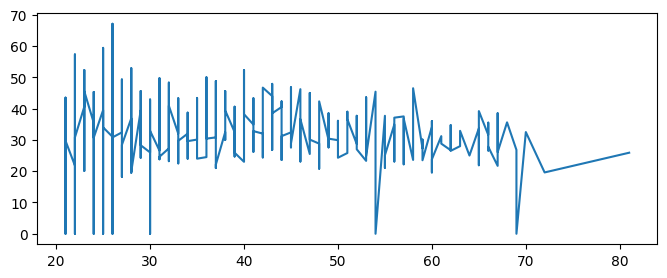

In [23]:
plt.figure(figsize=(8, 3))

plt.plot(df['Age'], df['BMI'])

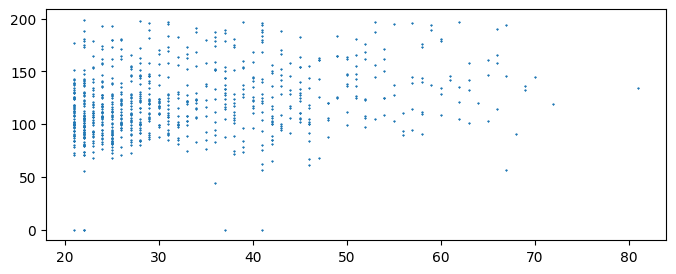

In [26]:
plt.figure(figsize=(8, 3))

plt.plot(df['Age'], df['Glucose'], '*', ms= 1)

In [27]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.140275,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152237,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.140275,0.152237,1.000000,0.208585,0.089489,0.282391,0.039344,0.238730,0.065642
SkinThickness,-0.081672,0.057328,0.208585,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.089489,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.282391,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.039344,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.238730,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065642,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [28]:
! pip install seaborn

<Axes: >

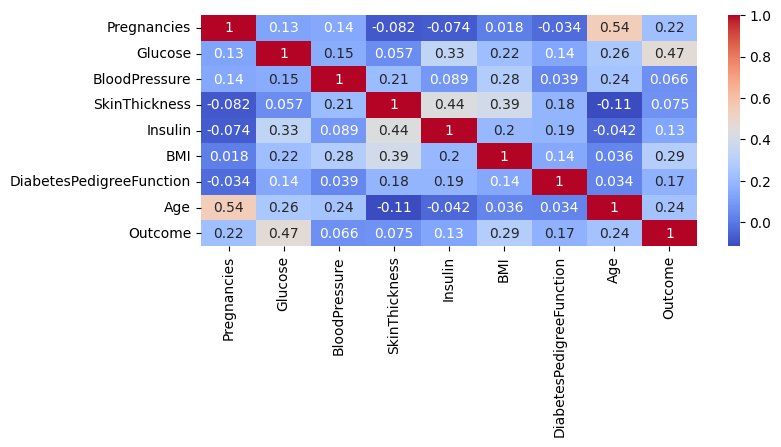

In [30]:
import seaborn as sns

plt.figure(figsize=(8,3))
sns.heatmap(df.corr(), annot= True, cmap = 'coolwarm')

In [31]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [32]:
df = df.drop(['Pregnancies', 'BloodPressure', 'SkinThickness'], axis=1)
df.head(5)

,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,126,120,27.4,0.515,21,0
1,99,160,36.6,0.453,21,0
2,114,200,38.1,0.289,21,0
3,84,0,0.0,0.304,21,0
4,78,40,36.9,0.434,21,0


In [34]:
X =df.drop(['Outcome'], axis = 1)
y = df['Outcome']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state=42
)

In [36]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
y_pred = log_reg.predict(X_test)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1])

In [39]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
accuracy_score(y_test, y_pred)

0.7532467532467533

In [40]:
print(f"{accuracy_score(y_test, y_pred) = }")
print(f"{recall_score(y_test, y_pred) = }")
print(f"{f1_score(y_test, y_pred) = }")
print(f"{precision_score(y_test, y_pred) = }")

accuracy_score(y_test, y_pred) = 0.7532467532467533
recall_score(y_test, y_pred) = 0.5714285714285714
f1_score(y_test, y_pred) = 0.6545454545454545
precision_score(y_test, y_pred) = 0.7659574468085106


In [41]:
from sklearn.svm import LinearSVC

Lin_svc = LinearSVC()
Lin_svc.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [42]:
y_pred_svc = Lin_svc.predict(X_test)

In [43]:
print(f"{accuracy_score(y_test, y_pred_svc) = }")
print(f"{recall_score(y_test, y_pred_svc) = }")
print(f"{f1_score(y_test, y_pred_svc) = }")
print(f"{precision_score(y_test, y_pred_svc) = }")

accuracy_score(y_test, y_pred_svc) = 0.7597402597402597
recall_score(y_test, y_pred_svc) = 0.5714285714285714
f1_score(y_test, y_pred_svc) = 0.6605504587155964
precision_score(y_test, y_pred_svc) = 0.782608695652174
